<a href="https://www.kaggle.com/code/mdtahmedulhassan/gold-price-prediction-random-forest-regressor?scriptVersionId=309093031" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Gold Price Prediction 💰

## Objective
### Predict gold prices using financial indicators like SPX, GLD, USO, SLV, EUR/USD.

## Why this matters?
### Gold is a hedge against inflation, so predicting it helps investors.

## Importing all the necessary libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

## Loading the data as df

In [44]:
df = pd.read_csv('/kaggle/input/datasets/altruistdelhite04/gold-price-data/gld_price_data.csv')

## Exploratory Data Analysis (EDA)

In [45]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [47]:
df.isna().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


## Dropping the Date Column


In [50]:
df.drop(columns=['Date'],inplace=True)
df.head(3)

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.180,1.471692
1,1447.160034,85.570000,78.370003,15.285,1.474491
2,1411.630005,85.129997,77.309998,15.167,1.475492


## Correlation Heatmap

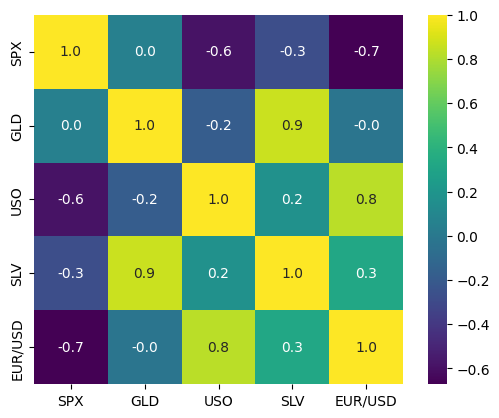

In [51]:
sns.heatmap(df.corr(),annot=True,cbar=True,square=True,fmt='.1f',cmap='viridis')
plt.show()

## Correlation with the GLD column

In [52]:
df.corr().GLD

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

## Distribution Plot of GLD

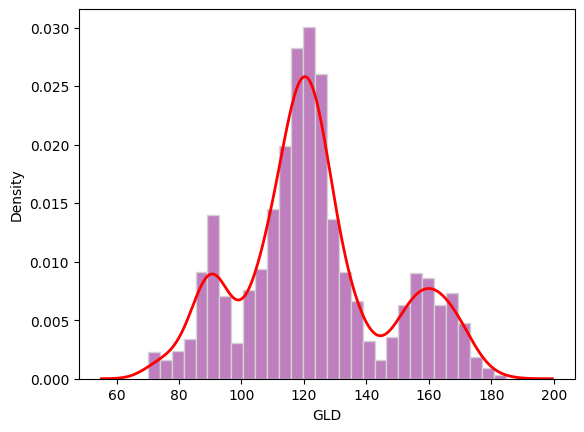

In [53]:
sns.histplot(df['GLD'], stat='density', bins=30, color='purple',alpha=.5,edgecolor='lightgrey')
sns.kdeplot(df['GLD'], color='red', linewidth=2)
plt.show()

## Splitting the predictor and target columns

In [54]:
x=df.drop(columns='GLD')
y=df['GLD']

In [55]:
x.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [56]:
y.head()

0    84.860001
1    85.570000
2    85.129997
3    84.769997
4    86.779999
Name: GLD, dtype: float64

## Generating train and test data

In [57]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=42)

### Splits data into 80% training and 20% testing. random_state=42 ensures reproducibility.

## Model Training by Random Forest Regressor

In [58]:
model= RandomForestRegressor(n_estimators=100)

### Building and training a Random Forest — an ensemble of 100 decision trees. Each tree learns slightly different patterns; their average forms the final prediction.

In [59]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [60]:
y_prediction=model.predict(x_test)

In [61]:
print(y_prediction)

[122.68879981 130.39740252 127.64770023  96.57129774 118.62350047
 114.21409911 124.85690102 117.7829994  108.01020113  98.47699966
  95.34229933 167.66719884 149.78170083 116.16350038 170.78150045
  84.92799955 123.48889877 109.05489722 113.33290083 131.76930308
 124.31779864 113.62750099 115.67780012 108.70000004 108.63480151
 125.85049944 118.52610034 112.43609899 113.53290154 125.48359899
 145.98410187  89.56149978 168.04299946 113.57479959 108.44440087
 120.13010097 142.3968988  161.22140115 173.95049783 153.01070133
 119.26380106 113.64770071 121.35799962 113.6831991  122.26900009
 107.9268008   88.04289926 114.35539933 129.69720217 118.01890116
 104.32650005 129.62290228 107.24099845 160.80460408 131.88820059
 118.10679991 147.01280081 136.38510203  95.61700129 124.59520142
 115.39209866  86.08280099 104.24189898 114.09050084  84.15929927
 122.39210024 116.49219904 113.50830187 165.3573037   92.32960028
  80.14990091 160.70370077 158.36000191 106.56959989 150.30920122
 109.53629

## Calculating R-squared score

In [62]:
r2=metrics.r2_score(y_test,y_prediction)
print('The value of R-squared is:',r2)

The value of R-squared is: 0.9889168904082534


### R² (coefficient of determination) measures how well the model explains variance in gold prices. A score close to 1.0 is excellent and R-squared score of our model is .99 which indicates our model is good. 

## Comparing the actual and predicted data using a plot

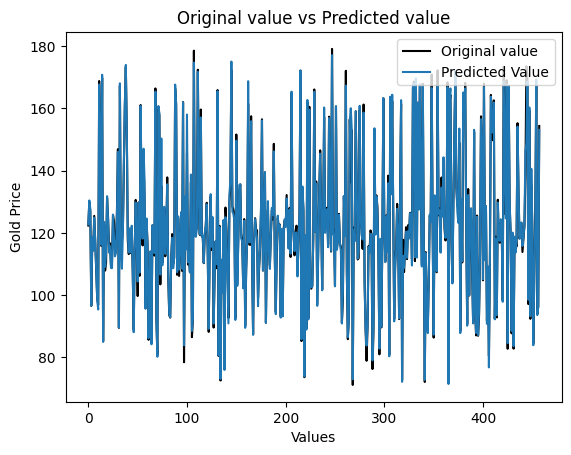

In [63]:
y_test=list(y_test)
plt.plot(y_test,color='black',label='Original value')
plt.plot(y_prediction,label='Predicted Value')
plt.title('Original value vs Predicted value')
plt.legend(loc='upper right')
plt.xlabel('Values')
plt.ylabel('Gold Price')
plt.show()